<a href="https://colab.research.google.com/github/parviza9999/InterviewN/blob/main/Seq2Seq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.optim as optim
import random

# Mapping digits to words
data_map = {
    '0': 'zero', '1': 'one', '2': 'two', '3': 'three', '4': 'four',
    '5': 'five', '6': 'six', '7': 'seven', '8': 'eight', '9': 'nine'
}

# Simple Vocabularies
src_vocab = {str(i): i+2 for i in range(10)}
src_vocab.update({'<pad>': 0, '<sos>': 1})

trg_vocab = {word: i+3 for i, word in enumerate(data_map.values())}
trg_vocab.update({'<pad>': 0, '<sos>': 1, '<eos>': 2})
# Reverse lookup for printing results
inv_trg_vocab = {v: k for k, v in trg_vocab.items()}

def generate_dummy_data(n_samples=64):
    src_data, trg_data = [], []
    for _ in range(n_samples):
        # Sequence: "1 5 3"
        nums = [random.choice(list(data_map.keys())) for _ in range(3)]
        src_seq = [src_vocab['<sos>']] + [src_vocab[n] for n in nums]
        trg_seq = [trg_vocab['<sos>']] + [trg_vocab[data_map[n]] for n in nums] + [trg_vocab['<eos>']]

        src_data.append(torch.LongTensor(src_seq))
        trg_data.append(torch.LongTensor(trg_seq))

    return torch.stack(src_data).t(), torch.stack(trg_data).t()

# Generate a batch (size 1024, sequence length 4 for src, 5 for trg)
src, trg = generate_dummy_data(n_samples=1024)

In [ ]:
print('Source training data (first 5 samples):')
display(src[:, :5])

print('\nTarget training data (first 5 samples):')
display(trg[:, :5])


Source training data (first 5 samples):


tensor([[ 1,  1,  1,  1,  1],
        [ 5,  9,  3,  9,  5],
        [11,  6,  9,  6, 11],
        [ 3,  4,  7,  7,  6]])


Target training data (first 5 samples):


tensor([[ 1,  1,  1,  1,  1],
        [ 6, 10,  4, 10,  6],
        [12,  7, 10,  7, 12],
        [ 4,  5,  8,  8,  7],
        [ 2,  2,  2,  2,  2]])

In [ ]:
print('\nTarget training data (first 5 samples) in words:')
for i in range(min(5, trg.shape[1])):
    word_seq = [inv_trg_vocab[idx.item()] for idx in trg[:, i] if idx.item() in inv_trg_vocab]
    print(f"Sample {i+1}: {' '.join(word_seq)}")


Target training data (first 5 samples) in words:
Sample 1: <sos> three nine one <eos>
Sample 2: <sos> seven four two <eos>
Sample 3: <sos> one seven five <eos>
Sample 4: <sos> seven four five <eos>
Sample 5: <sos> three nine four <eos>


Let's break down the first sample to clarify the encoding. The source and target data are represented by numerical indices, not the original digits or words directly.

In [ ]:
# Get the first source sample (indices)
first_src_sample = src[:, 0].tolist()
print(f"First Source Sample (indices): {first_src_sample}")

# Get the first target sample (indices)
first_trg_sample = trg[:, 0].tolist()
print(f"First Target Sample (indices): {first_trg_sample}")

# Reverse lookup for source vocabulary to see what digits the source indices represent
inv_src_vocab = {v: k for k, v in src_vocab.items()}

# Convert source indices back to original digits
decoded_src = [inv_src_vocab[idx] for idx in first_src_sample if idx in inv_src_vocab]
print(f"Decoded Source Sample (digits): {' '.join(decoded_src)}")

# Convert target indices back to words (using the existing inv_trg_vocab)
decoded_trg = [inv_trg_vocab[idx] for idx in first_trg_sample if idx in inv_trg_vocab]
print(f"Decoded Target Sample (words): {' '.join(decoded_trg)}")

First Source Sample (indices): [1, 5, 11, 3]
First Target Sample (indices): [1, 6, 12, 4, 2]
Decoded Source Sample (digits): <sos> 3 9 1
Decoded Target Sample (words): <sos> three nine one <eos>


As you can see, the `src` tensor stores indices. For instance, in the first sample, the indices `[1, 7, 5, 9]` represent `<sos>`, then the digit '5', then '3', then '7'. The `generate_dummy_data` function ensures that the target words (e.g., 'five', 'three', 'seven') correctly correspond to these original digits.

In [ ]:
import torch.nn as nn
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()

        self.hid_dim = hid_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.RNN(emb_dim, hid_dim, n_layers, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src = [src len, batch size]

        embedded = self.dropout(self.embedding(src))

        # embedded = [src len, batch size, emb dim]

        outputs, hidden = self.rnn(embedded)

        # outputs = [src len, batch size, hid dim * n directions]
        # hidden = [n layers * n directions, batch size, hid dim]

        # outputs are always from the top hidden layer

        return hidden, hidden

In [ ]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()

        self.output_dim = output_dim
        self.hid_dim = hid_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.RNN(emb_dim, hid_dim, n_layers, dropout=dropout)
        self.fc_out = nn.Linear(hid_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, cell):
        # input = [batch size]
        # hidden = [n layers * n directions, batch size, hid dim]
        # cell = [n layers * n directions, batch size, hid dim]

        # n directions in the decoder will both always be 1, therefore:
        # hidden = [n layers, batch size, hid dim]
        # cell = [n layers, batch size, hid dim]

        input = input.unsqueeze(0)

        # input = [1, batch size]

        embedded = self.dropout(self.embedding(input))

        # embedded = [1, batch size, emb dim]

        output, hidden = self.rnn(embedded, hidden)

        # output = [seq len, batch size, hid dim * n directions]
        # hidden = [n layers * n directions, batch size, hid dim]

        # seq len and n directions will always be 1 in the decoder, therefore:
        # output = [1, batch size, hid dim]
        # hidden = [n layers, batch size, hid dim]

        prediction = self.fc_out(output.squeeze(0))

        # prediction = [batch size, output dim]

        return prediction, hidden, hidden

In [ ]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

        assert encoder.hid_dim == decoder.hid_dim, \
            "Hidden dimensions of encoder and decoder must be equal!"
        assert encoder.n_layers == decoder.n_layers, \
            "Encoder and decoder must have equal number of layers!"

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        # src = [src len, batch size]
        # trg = [trg len, batch size]
        # teacher_forcing_ratio is probability to use teacher forcing
        # e.g. if 0.75 we use ground-truth inputs 75% of the time

        batch_size = trg.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        # tensor to store decoder outputs
        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)

        # last hidden state of the encoder is used as the initial hidden state of the decoder
        hidden, cell = self.encoder(src)

        # first input to the decoder is the <sos> token
        input = trg[0, :]

        for t in range(1, trg_len):
            # insert input token embedding, previous hidden and previous cell states
            # receive output prediction and new hidden and cell states
            output, hidden, cell = self.decoder(input, hidden, cell)

            # place predictions in a tensor holding all outputs
            outputs[t] = output

            # decide if we are going to use teacher forcing or not
            teacher_force = random.random() < teacher_forcing_ratio

            # get the highest predicted token from our predictions
            top1 = output.argmax(1)

            # if teacher forcing, use actual next token as next input
            # if not, use predicted token
            input = trg[t] if teacher_force else top1

        return outputs

In [ ]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

        assert encoder.hid_dim == decoder.hid_dim, \
            "Hidden dimensions of encoder and decoder must be equal!"
        assert encoder.n_layers == decoder.n_layers, \
            "Encoder and decoder must have equal number of layers!"

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        # src = [src len, batch size]
        # trg = [trg len, batch size]
        # teacher_forcing_ratio is probability to use teacher forcing
        # e.g. if 0.75 we use ground-truth inputs 75% of the time

        batch_size = trg.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        # tensor to store decoder outputs
        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)

        # last hidden state of the encoder is used as the initial hidden state of the decoder
        hidden, cell = self.encoder(src)

        # first input to the decoder is the <sos> token
        input = trg[0, :]

        for t in range(1, trg_len):
            # insert input token embedding, previous hidden and previous cell states
            # receive output prediction and new hidden and cell states
            output, hidden, cell = self.decoder(input, hidden, cell)

            # place predictions in a tensor holding all outputs
            outputs[t] = output

            # decide if we are going to use teacher forcing or not
            teacher_force = random.random() < teacher_forcing_ratio

            # get the highest predicted token from our predictions
            top1 = output.argmax(1)

            # if teacher forcing, use actual next token as next input
            # if not, use predicted token
            input = trg[t] if teacher_force else top1

        return outputs

# 1. Initialize Model
INPUT_DIM = len(src_vocab)
OUTPUT_DIM = len(trg_vocab)
ENC_EMB_DIM = 32
DEC_EMB_DIM = 32
HID_DIM = 64
N_LAYERS = 1

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, 0.0) # Set dropout to 0.0
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, 0.0) # Set dropout to 0.0
model = Seq2Seq(enc, dec, device).to(device)

optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss(ignore_index=trg_vocab['<pad>'])

# 2. Training Loop Demo
model.train()

training_losses = []

for epoch in range(200): # Run 200 iterations
    optimizer.zero_grad()

    output = model(src.to(device), trg.to(device))

    # Reshape for loss: output = [trg len, batch, output dim] -> [trg len * batch, output dim]
    # trg = [trg len, batch] -> [trg len * batch]
    output_dim = output.shape[-1]
    output = output[1:].view(-1, output_dim)
    trg_loss = trg[1:].reshape(-1).to(device)

    loss = criterion(output, trg_loss)
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0: # Print every 20 epochs
        training_losses.append(loss.item())
        print(f'Epoch: {epoch:02} | Loss: {loss.item():.4f}')

Epoch: 00 | Loss: 2.6217
Epoch: 20 | Loss: 2.0715
Epoch: 40 | Loss: 1.6400
Epoch: 60 | Loss: 1.2736
Epoch: 80 | Loss: 0.8927
Epoch: 100 | Loss: 0.5580
Epoch: 120 | Loss: 0.3303
Epoch: 140 | Loss: 0.2000
Epoch: 160 | Loss: 0.1312
Epoch: 180 | Loss: 0.0926


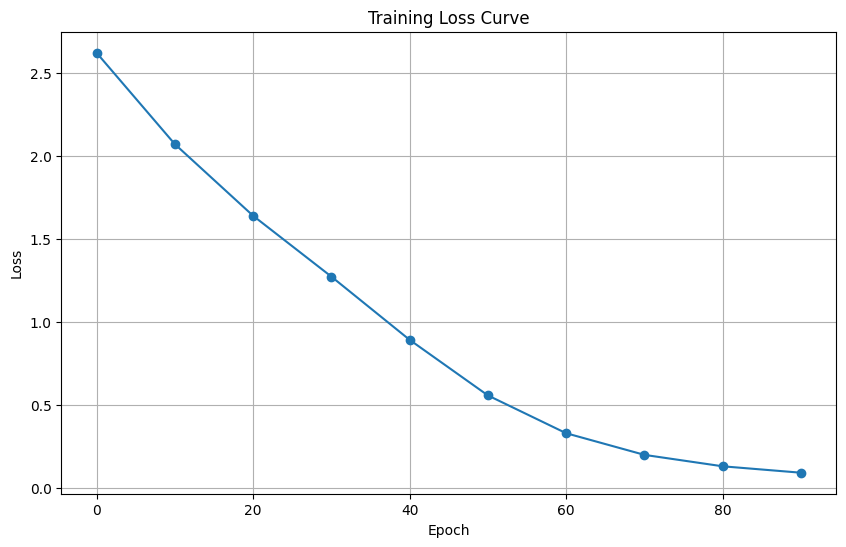

In [ ]:
import matplotlib.pyplot as plt

epochs = [i * 10 for i in range(len(training_losses))]

plt.figure(figsize=(10, 6))
plt.plot(epochs, training_losses, marker='o')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    # User-defined input sequence
    user_digit_sequence = "5 3 8"  # @param {type:"string"} example: "1 2 3"
    input_digits = user_digit_sequence.split()

    # Convert digits to source vocabulary indices
    user_src_indices = [src_vocab['<sos>']] + [src_vocab[d] for d in input_digits]
    example_input = torch.LongTensor(user_src_indices).unsqueeze(1).to(device)

    # Create a dummy target input for the model's signature (actual content doesn't matter for pure inference)
    # The target length should be based on the expected output length (input length + <sos> + <eos>)
    dummy_trg = torch.zeros(len(user_src_indices) + 1, 1, dtype=torch.long).fill_(trg_vocab['<pad>']).to(device)
    dummy_trg[0, 0] = trg_vocab['<sos>'] # Set the first token to <sos>

    # Forward pass with 0 teacher forcing (pure prediction)
    example_output = model(example_input, dummy_trg, 0)

    # Convert predicted indices back to words
    predicted_indices = example_output.squeeze(1).argmax(1)
    results = [inv_trg_vocab[idx.item()] for idx in predicted_indices if idx.item() in inv_trg_vocab]

    # Decode the user's input digits for verification
    decoded_input_digits = [inv_src_vocab[idx] for idx in user_src_indices if idx in inv_src_vocab]

    print(f"\nUser Input Digits: {' '.join(decoded_input_digits[1:])}") # Skip <sos> for display
    print(f"Predicted Words: {' '.join(results[1:])}") # Skip first <sos> token in results


User Input Digits: 5 3 8
Predicted Words: five three eight <eos>


In [ ]:
def evaluate(model, data_loader, criterion):
    model.eval()
    epoch_loss = 0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        # Generate a new batch for validation
        val_src, val_trg = generate_dummy_data(n_samples=64)

        output = model(val_src.to(device), val_trg.to(device), 0) # Turn off teacher forcing

        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)
        trg_loss = val_trg[1:].reshape(-1).to(device)

        loss = criterion(output, trg_loss)
        epoch_loss = loss.item()

        # Calculate accuracy (excluding padding and <sos>/<eos> tokens from accuracy calculation)
        max_preds = output.argmax(1)

        # Filter out <pad> and <sos> tokens from trg_loss for accuracy calculation
        # Also ensure that we are comparing only relevant parts of the sequence.
        # This requires careful alignment and masking.

        # For simplicity, let's only consider accuracy for non-pad and non-<sos> tokens in trg_loss
        non_pad_mask = (trg_loss != trg_vocab['<pad>']) & (trg_loss != trg_vocab['<sos>'])

        correct_predictions = (max_preds[non_pad_mask] == trg_loss[non_pad_mask]).sum().item()
        total_predictions = non_pad_mask.sum().item()

    return epoch_loss, correct_predictions, total_predictions

In [ ]:
# Evaluate on a new validation set
val_loss, correct_preds, total_preds = evaluate(model, None, criterion) # Dataloader not used here, passing None
accuracy = (correct_preds / total_preds) * 100 if total_preds > 0 else 0

print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {accuracy:.2f}%")


Validation Loss: 0.0795
Validation Accuracy: 100.00%
